### Setup

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import pandas as pd
from scipy.stats import poisson


In [3]:
def quick_plot(func,x = None,y = None,yerr = None,label = None , title = None , x_title = None , 
               y_title = None, p0 = None,log = '.'):
    """
    Uses Scipy curve_fit to automatically create comparison plot and residual plot.
    MUST define func() before using function!
    Can take inf amount of function arguments!
    Stores Scipy Perr and popt
    """

    popt, pcov = curve_fit(func,x,y,sigma = yerr, absolute_sigma = True, p0=p0)

    perr = np.sqrt(np.diag(pcov))
    
    y_fit = func(x,*popt)
    
    print(*popt)
    print(*perr)

    plt.errorbar (x, y,fmt = 'o',yerr = yerr,label = label )
    plt.plot(x,y_fit)
    plt.title(title)
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.grid()
    plt.show()


    resid = y - y_fit

    plt.errorbar(x,resid,yerr = yerr, fmt = 'o',label = label)
    plt.axhline(y = 0, color = 'black', linestyle = '--')
    plt.grid()
    plt.legend()
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(title)
    plt.show()


### 7.4.1: Config DONE

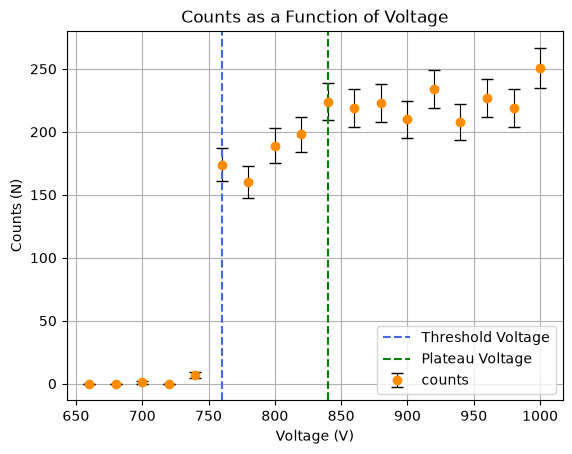

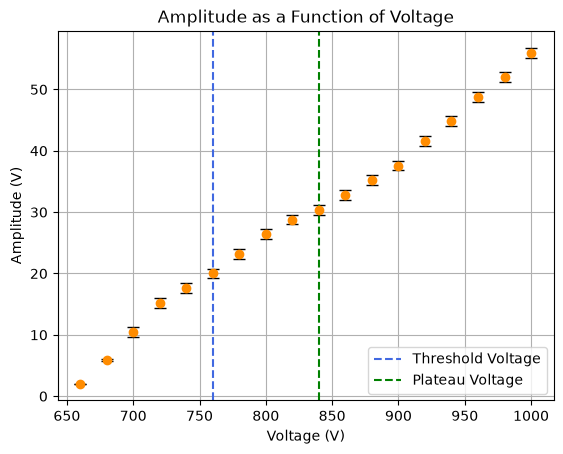

,Tube Voltage,Amp_1,Amp_2,unc_amp,Count,Time
0,660,0.0,2.04,0.00,0,5
1,680,6.0,5.92,0.16,0,5
2,700,11.2,10.40,0.80,1,5
3,720,16.0,15.20,0.80,0,5
4,740,17.6,17.60,0.80,7,5
5,760,20.8,20.00,0.80,174,5
6,780,24.0,23.20,0.80,160,5
7,800,27.2,26.40,0.80,189,5
8,820,28.0,28.80,0.80,198,5
9,840,30.4,30.40,0.80,224,5


In [79]:
df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - 7.4.1_ Configuration.csv')

counts = df.iloc[:,4]
voltage = df.iloc[:,0]
amplitude = df.iloc[:,2]
unc_amp = df.iloc[:,3]

plt.errorbar(voltage,counts,yerr = np.sqrt(df.iloc[:,4]),
             fmt = 'o',color = 'darkorange', ecolor = 'black', elinewidth=0.8, capsize = 4, label = 'counts')
plt.axvline(x=760,linestyle = '--',color = 'royalblue',label = 'Threshold Voltage')
plt.axvline(x=840,linestyle = '--',color = 'green',label = "Plateau Voltage")
plt.legend()
plt.title('Counts as a Function of Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Counts (N)')
plt.grid(True)
plt.show()

plt.errorbar(voltage,amplitude,yerr = unc_amp,fmt = 'o',color = 'darkorange', ecolor = 'black', elinewidth=0.8, capsize = 4)
plt.axvline(x=760,linestyle = '--',color = 'royalblue',label = 'Threshold Voltage')
plt.axvline(x=840,linestyle = '--',color = 'green',label = "Plateau Voltage")
plt.legend()
plt.title('Amplitude as a Function of Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Amplitude (V)')
plt.grid(True)
plt.show()
df


### 7.4.2: Resistor Config DONE

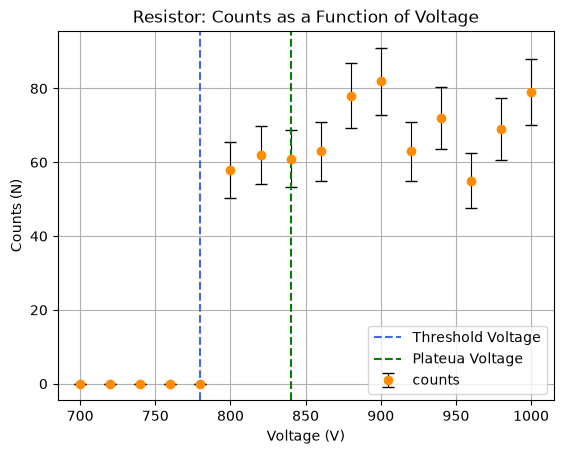

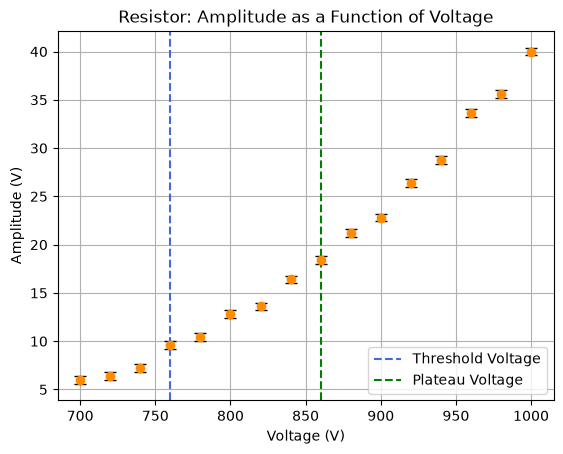

,Tube Voltage,Amp,unc_amp,Count,Time,Corrected_CR
0,700,6.0,0.4,0,5,0.0
1,720,6.4,0.4,0,5,0.0
2,740,7.2,0.4,0,5,0.0
3,760,9.6,0.4,0,5,0.0
4,780,10.4,0.4,0,5,0.0
5,800,12.8,0.4,58,5,6.3
6,820,13.6,0.4,62,5,7.1
7,840,16.4,0.4,61,5,6.9
8,860,18.4,0.4,63,5,7.3
9,880,21.2,0.4,78,5,10.3


In [78]:
df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - 7.4.4_ Dead Time-config (resistor).csv')

counts = df.iloc[:,3]
voltage = df.iloc[:,0]
amplitude = df.iloc[:,1]
unc_amp = df.iloc[:,2]

plt.errorbar(voltage,counts,yerr = np.sqrt(df.iloc[:,3]),
             fmt = 'o',color = 'darkorange', ecolor = 'black', elinewidth=0.8, capsize = 4, label = 'counts')
plt.axvline(x=780,linestyle = '--',color = 'royalblue',label = 'Threshold Voltage')
plt.axvline(x=840,linestyle = '--',color = 'green',label = "Plateua Voltage")
plt.legend()
plt.title('Resistor: Counts as a Function of Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Counts (N)')
plt.grid(True)
plt.show()

plt.errorbar(voltage,amplitude,yerr = unc_amp,fmt = 'o',color = 'darkorange', ecolor = 'black', elinewidth=0.8, capsize = 4)
plt.axvline(x=760,linestyle = '--',color = 'royalblue',label = 'Threshold Voltage')
plt.axvline(x=860,linestyle = '--',color = 'green',label = "Plateau Voltage")
plt.legend()
plt.title('Resistor: Amplitude as a Function of Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Amplitude (V)')
plt.grid(True)
plt.show()
df

### 7.4.3 POSSION DIST DONE

χ² = 11.66
χ²v = 0.90


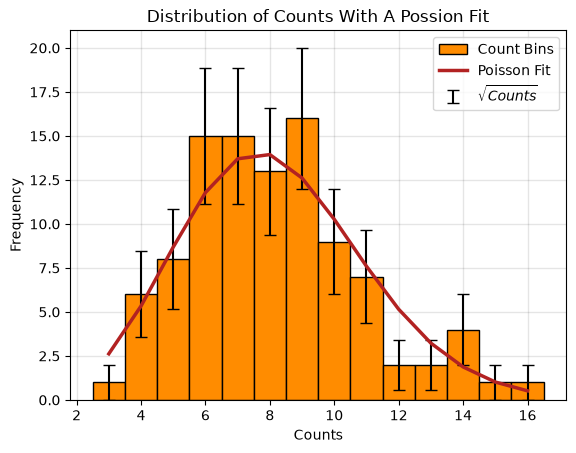

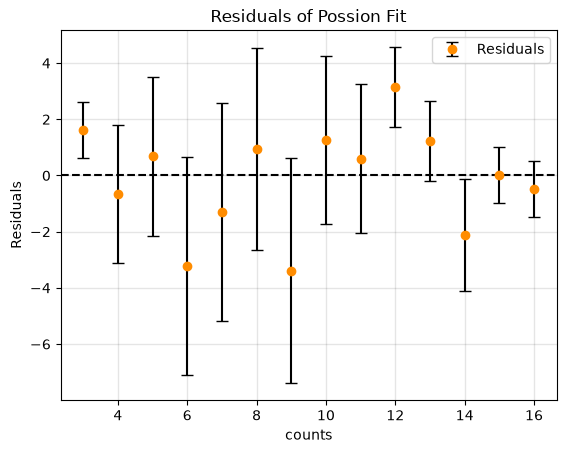

In [20]:
from scipy.special import factorial


df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - 7.4.3_ Poisson.csv')

counts = df.iloc[:,1]
trials = df.iloc[:,0]
total_trials = len(counts)

sigma = np.sqrt(counts)

mean = np.mean(counts)


x_range = np.arange(int(counts.min()), int(counts.max()) + 1)


bins = np.arange(counts.min() - 0.5, counts.max() + 1.5, 1)

freq, bins, patches = plt.hist(counts,bins=bins,color='darkorange',edgecolor='black',label="Count Bins")

bincenters = (bins[:-1] + bins[1:]) * 0.5


scaled_pmf = poisson.pmf(x_range, mean) * total_trials


errors = np.sqrt(freq)


chi_2 = np.sum(((scaled_pmf - freq)**2) / errors**2)
dof = len(x_range) - 1
chiv_2 = chi_2/dof 

print(f"χ² = {chi_2:.2f}")
print(f"χ²v = {chiv_2:.2f}")

plt.errorbar(bincenters,freq,yerr=errors,fmt='none',ecolor='black',capsize=4,elinewidth=1.5,label=r'$\sqrt{Counts}$')

plt.plot( x_range,scaled_pmf,color='firebrick',linewidth=2.5,label='Poisson Fit')

plt.legend()

plt.grid(True, color='black', linewidth=1, alpha=0.1)
plt.gca().set_axisbelow(True)
plt.title('Distribution of Counts With A Possion Fit')
plt.ylabel('Frequency')
plt.xlabel('Counts')
plt.show()

resid = scaled_pmf - freq

plt.errorbar(x_range,resid,yerr =errors, fmt = 'o', color='darkorange',ecolor='black',capsize=4,elinewidth=1.5,label='Residuals')
plt.axhline(y = 0,color = 'black',linestyle = '--')
plt.legend()
plt.grid(True, color='black', linewidth=1, alpha=0.1)
plt.title('Residuals of Possion Fit')
plt.xlabel('counts')
plt.ylabel('Residuals')
plt.show()


### 7.4.4 Dead Time DONE

In [ ]:
#Visual

T = 530*np.log(2) 

print(T)

367.368005696771


In [37]:
#Two Sources
df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - 7.4.4 DeadTime_ Mult Sources.csv')

df = df.iloc[1:,:]

df = df.astype(float)

time = np.mean(df.iloc[:,4])

na = np.mean(df.iloc[:,1])
nb = np.mean(df.iloc[:,2])
nab = np.mean(df.iloc[:,3])

na_unc = np.sqrt(np.sum(df.iloc[:,1]))/3
nb_unc = np.sqrt(np.sum(df.iloc[:,2]))/3
nab_unc = np.sqrt(np.sum(df.iloc[:,3]))/3

ra = na/time
rb = nb/time
rab = nab/time

ra_unc = na_unc/time
rb_unc = nb_unc/time
rab_unc = nab_unc/time

tau = ((ra+rb-rab)/(2*ra*rb))*1e6

dna_unc = (1/(2*ra*rb)) - ((ra+rb-rab)/(2*(ra**2)*rb))
dnb_unc = (1/(2*ra*rb)) - ((ra+rb-rab)/(2*ra*rb**2))
dnab_unc = -1/(2*ra*rb)

sigma_tau = np.sqrt((ra_unc * dna_unc**2) + (rb_unc * dnb_unc**2) + (rab_unc * dnab_unc**2)) *1e6

print(f'{tau} microseconds')
print(f"Dead Time (μs) = {tau:.6f} ± {sigma_tau:.6f} μs ")




364.704556231168 microseconds
Dead Time (μs) = 364.704556 ± 10.070359 μs 


### 7.4.5 Lead Absorption

Slope (m)       = -0.110401 ± 0.002051 mm⁻¹
Intercept (b)   = 2.611045 ± 0.023287

Attenuation coefficient (μ) = 0.110401 ± 0.002051 mm⁻¹
Attenuation coefficient (μ) = 0.011040 ± 0.000205 cm⁻¹
Chi-squared (χ²)      = 43.778601
Reduced chi-squared   = 7.296434

Fit equation:
ln(R_c) = (-0.110401)x + (2.611045)


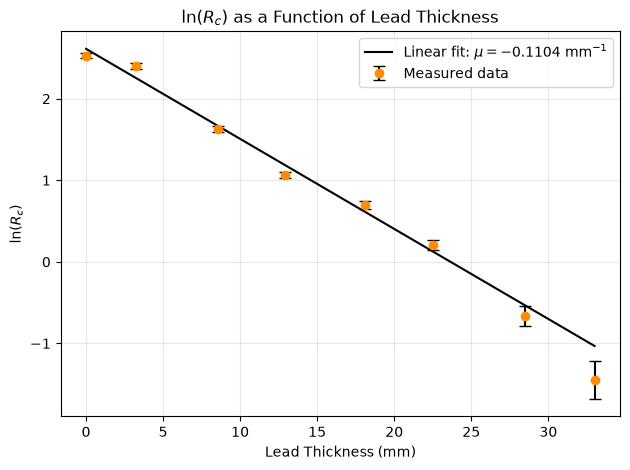

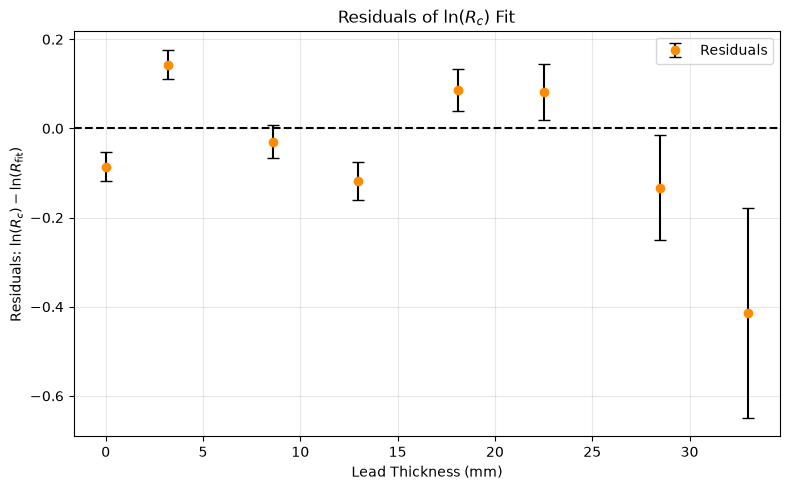

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


df = pd.read_csv(
    '/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - 7.5 Lead Absorption.csv'
)

df_b = pd.read_csv(
    '/Users/cadenjensen/Desktop/Phys 133/gammalab/data/phys_133_gamma_ray - Daily Background Count.csv'
)




back_count = df_b.iloc[1, 2]
back_time = df_b.iloc[1, 3]
back_rate = df_b.iloc[1, 4]

sigma_back = np.sqrt(back_count) / back_time




thick = df.iloc[:, 0]
counts = df.iloc[:, 1]
time = df.iloc[:, 2]
meas_rate = df.iloc[:, 3]

sigma_rate = np.sqrt(counts) / time



R_c = (counts / time) - (back_count / back_time)

R_sigma = np.sqrt(np.square(sigma_back)+ np.square(sigma_rate))




R_cln = np.log(R_c)

R_sigln = R_sigma / R_c



def func(thick, m, b):
    return m * thick + b


popt, pcov = curve_fit(func,thick,R_cln,sigma=R_sigln,absolute_sigma=True)

new_fit = func(thick, *popt)

resid = R_cln - func(thick, *popt)



slope = popt[0]
intercept = popt[1]

slope_error = np.sqrt(pcov[0, 0])
intercept_error = np.sqrt(pcov[1, 1])

mu = -slope
mu_error = slope_error


chi2 = np.sum(resid**2 / R_sigln**2)

dof = len(thick) - len(popt)

chiv2 = chi2 / dof



print(f"Slope (m)       = {slope:.6f} ± {slope_error:.6f} mm⁻¹")
print(f"Intercept (b)   = {intercept:.6f} ± {intercept_error:.6f}")

print()
print(f"Attenuation coefficient (μ) = {mu:.6f} ± {mu_error:.6f} mm⁻¹")
print(f"Attenuation coefficient (μ) = {mu/10:.6f} ± {mu_error/10:.6f} cm⁻¹")


print(f"Chi-squared (χ²)      = {chi2:.6f}")
print(f"Reduced chi-squared   = {chiv2:.6f}")

print()
print(f"Fit equation:")
print(f"ln(R_c) = ({slope:.6f})x + ({intercept:.6f})")




plt.errorbar(thick,R_cln,yerr=R_sigln,fmt='o',color='darkorange',ecolor='black',capsize=4,elinewidth=1.5,label='Measured data')

plt.plot(thick,new_fit,color='black',label=rf'Linear fit: $\mu={slope:.4f}\ \mathrm{{mm^{{-1}}}}$')

plt.xlabel('Lead Thickness (mm)')
plt.ylabel(r'$\ln(R_c)$')
plt.title(r'$\ln(R_c)$ as a Function of Lead Thickness')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.errorbar(thick,resid,yerr=R_sigln,fmt='o',color='darkorange',ecolor='black',capsize=4,elinewidth=1.5,label='Residuals')

plt.axhline(y=0,color='black',linestyle='--')

plt.xlabel('Lead Thickness (mm)')
plt.ylabel(r'Residuals: $\ln(R_c)-\ln(R_{\mathrm{fit}})$')
plt.title(r'Residuals of $\ln(R_c)$ Fit')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Intrinsic Capacitance and Resistance

In [ ]:
vo = 32.8 *1e6 #microvolts
vo_sig = 0.4 *1e6
tauo = 440 #microseconds

vc = 13.6 *1e6
vc_sig = 0.4*1e6
Ck = 0.002 #microfarads
tauc = 1040 #microseconds

C = (vc*Ck)/(vo-vc)

print(C) #microfarads

Q = C * vo

print(Q) #pico coloumbs 

R = tauo/C

print(R) # mega ohms


0.001416666666666667
46466.66666666667
310588.2352941176


### Coeffcient Derivation With Lab Manual Data

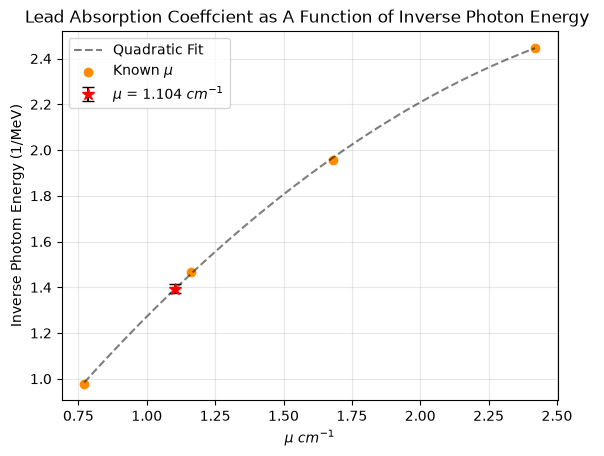

In [75]:
energy = np.array([0.4086,0.5108,0.6811,1.022])
coeff = np.array([2.42,1.68,1.16,0.771])


def func(coeff,a,b,c):
    return a*coeff**2 + b*coeff + c

popt, pcov = curve_fit(func,coeff, 1/energy)

new_fit = func(coeff,*popt)

a = popt[0]
b = popt[1]
c = popt[2]

point = 1/0.662

coefff = np.linspace(min(coeff),max(coeff),400)

plt.plot(coefff,func(coefff,*popt), linestyle = '--', color = 'black',alpha = 0.5,label = 'Quadratic Fit' )
plt.scatter(coeff,1/energy,marker='o',color='darkorange',label = r'Known $\mu$')
plt.errorbar(x = 1.104,y = func(1.104,*popt),yerr = 0.02051,fmt = '*',capsize = 4,ecolor = 'black',label = r'$\mu$ = 1.104 $cm^{-1}$',markersize = 9,color = 'red')
plt.legend()
plt.xlabel(r'$\mu$ $cm^{-1}$')
plt.ylabel("Inverse Photom Energy (1/MeV)")
plt.title('Lead Absorption Coeffcient as A Function of Inverse Photon Energy ')
plt.grid(alpha = 0.3)


